# 15 — `MNet1000`: forward + backward + per-parameter gradient norms

`MNet1000` is a 4-stage Conv2d backbone for multi-channel 1-second
EEG/MEG (≈ 19-270 channels at 1 kHz). Forward unfolds time, applies
depth-wise then point-wise 2D conv stacks with Mish activations, and
projects through two fully-connected layers to `len(classes)` logits.

Cap `batch ≤ 8` to fit CPU/GPU memory; `seq_len = 1000` is required
(`N_FC_IN = 15950` is hardcoded for that exact layout).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import scitex_nn

torch.manual_seed(42)

## Build a 4-class classifier on synthetic 19-channel EEG

In [2]:
batch, n_chs, seq_len, n_classes = 4, 19, 1000, 4
cfg = {
    "n_chs": n_chs,
    "n_fc1": 256,
    "n_fc2": 128,
    "d_ratio1": 0.5,
    "d_ratio2": 0.5,
    "classes": list(range(n_classes)),
}
model = scitex_nn.MNet1000(cfg)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

x = torch.randn(batch, n_chs, seq_len)
y_true = torch.randint(0, n_classes, (batch,))
logits = model(x)
print("logits.shape:", tuple(logits.shape))
assert logits.shape == (batch, n_classes)

loss = nn.functional.cross_entropy(logits, y_true)
loss.backward()
print(
    f"loss = {loss.item():.3f}; gradients flow through all {sum(1 for p in model.parameters() if p.grad is not None)} params"
)

params: 4,144,068
logits.shape: (4, 4)


loss = 1.367; gradients flow through all 20 params


## Per-parameter gradient norms

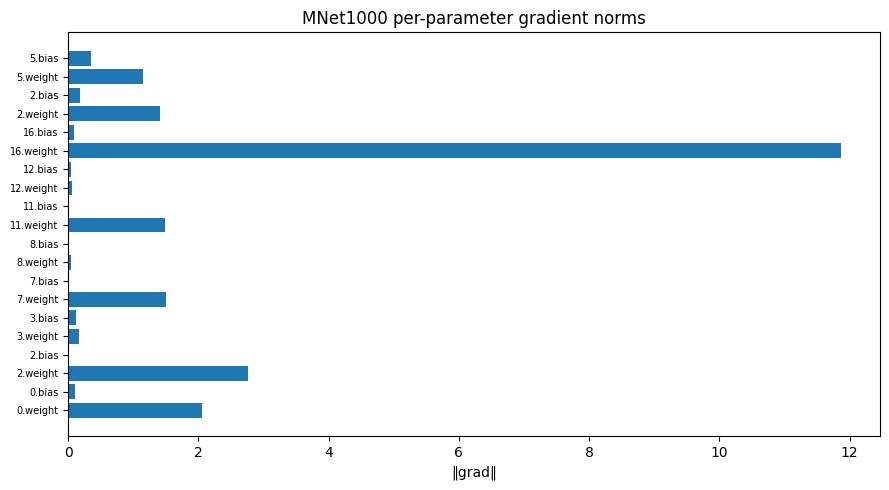

In [3]:
grads = [
    (name, p.grad.norm().item())
    for name, p in model.named_parameters()
    if p.grad is not None
]
labels = [".".join(n.split(".")[-2:]) for n, _ in grads]
values = [g for _, g in grads]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(values)), values)
ax.set_yticks(range(len(values)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("‖grad‖")
ax.set_title("MNet1000 per-parameter gradient norms")
fig.tight_layout()
plt.show()